In [1]:
import os, random, copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_score, recall_score, f1_score)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42); random.seed(42); np.random.seed(42)

BASE       = os.getcwd()
TRAIN_PATH = os.path.join(BASE, 'archive_extracted', 'Training')
TEST_PATH  = os.path.join(BASE, 'archive_extracted', 'Testing')

IMG_SIZE    = 128
BATCH_SIZE  = 32
NUM_CLASSES = 4
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']

print('Device:', DEVICE)


Device: cpu


In [3]:
# Standard transform (Models 1 & 2)
std_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

# ImageNet transform (Model 3 - MobileNetV2)
inet_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

std_test_ds  = datasets.ImageFolder(TEST_PATH, transform=std_test_transform)
inet_test_ds = datasets.ImageFolder(TEST_PATH, transform=inet_test_transform)

std_test_loader  = DataLoader(std_test_ds,  batch_size=BATCH_SIZE, shuffle=False)
inet_test_loader = DataLoader(inet_test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f'Test images: {len(std_test_ds)}')


Test images: 1600


In [5]:
# ── Model 1: Baseline CNN ────────────────────────────────────────────────────
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256), nn.ReLU(),
            nn.Linear(256, 4),
        )
    def forward(self, x): return self.classifier(self.features(x))


# ── Model 2: Improved CNN ────────────────────────────────────────────────────
class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.1),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.3),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 4),
        )
    def forward(self, x): return self.classifier(self.features(x))


print('Architectures defined.')


Architectures defined.


In [7]:
# ── Model 1 ──────────────────────────────────────────────────────────────────
model1 = BaselineCNN().to(DEVICE)
model1.load_state_dict(torch.load('model1_baseline.pth', map_location=DEVICE))
model1.eval()

# ── Model 2 ──────────────────────────────────────────────────────────────────
model2 = ImprovedCNN().to(DEVICE)
model2.load_state_dict(torch.load('model2_improved.pth', map_location=DEVICE))
model2.eval()

# ── Model 3 – Rebuild head then load weights ──────────────────────────────────
mobilenet = models.mobilenet_v2(weights=None)
in_features = mobilenet.classifier[1].in_features
mobilenet.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Linear(256, 4),
)
mobilenet.load_state_dict(torch.load('model3_mobilenet.pth', map_location=DEVICE))
model3 = mobilenet.to(DEVICE)
model3.eval()

print('All 3 models loaded successfully.')


All 3 models loaded successfully.


In [9]:
def evaluate(model, loader):
    criterion = nn.CrossEntropyLoss()
    total_loss, correct = 0, 0
    all_preds, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds       = outputs.argmax(1)
            correct    += (preds == labels).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = correct / len(loader.dataset)
    return acc, all_preds, all_labels


acc1, preds1, labels1 = evaluate(model1, std_test_loader)
acc2, preds2, labels2 = evaluate(model2, std_test_loader)
acc3, preds3, labels3 = evaluate(model3, inet_test_loader)

model_names = ['Baseline CNN', 'Improved CNN', 'MobileNetV2']
all_preds   = [preds1, preds2, preds3]
all_labels  = [labels1, labels2, labels3]

print('Evaluation complete.')


Evaluation complete.


In [11]:
results = {}
print(f'\n{"Model":<22} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1 Score":>10}')
print('=' * 68)

for name, preds, labels in zip(model_names, all_preds, all_labels):
    acc  = np.mean(np.array(preds) == np.array(labels))
    prec = precision_score(labels, preds, average='weighted', zero_division=0)
    rec  = recall_score(   labels, preds, average='weighted', zero_division=0)
    f1   = f1_score(       labels, preds, average='weighted', zero_division=0)
    results[name] = dict(accuracy=acc, precision=prec, recall=rec, f1=f1)
    print(f'{name:<22} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}')

best = max(results, key=lambda k: results[k]['f1'])
print(f'\n🏆 Best Model by F1: {best}  (F1 = {results[best]["f1"]:.4f})')



Model                    Accuracy  Precision     Recall   F1 Score
Baseline CNN               0.9319     0.9361     0.9319     0.9299
Improved CNN               0.8819     0.8873     0.8819     0.8785
MobileNetV2                0.8550     0.8630     0.8550     0.8512

🏆 Best Model by F1: Baseline CNN  (F1 = 0.9299)


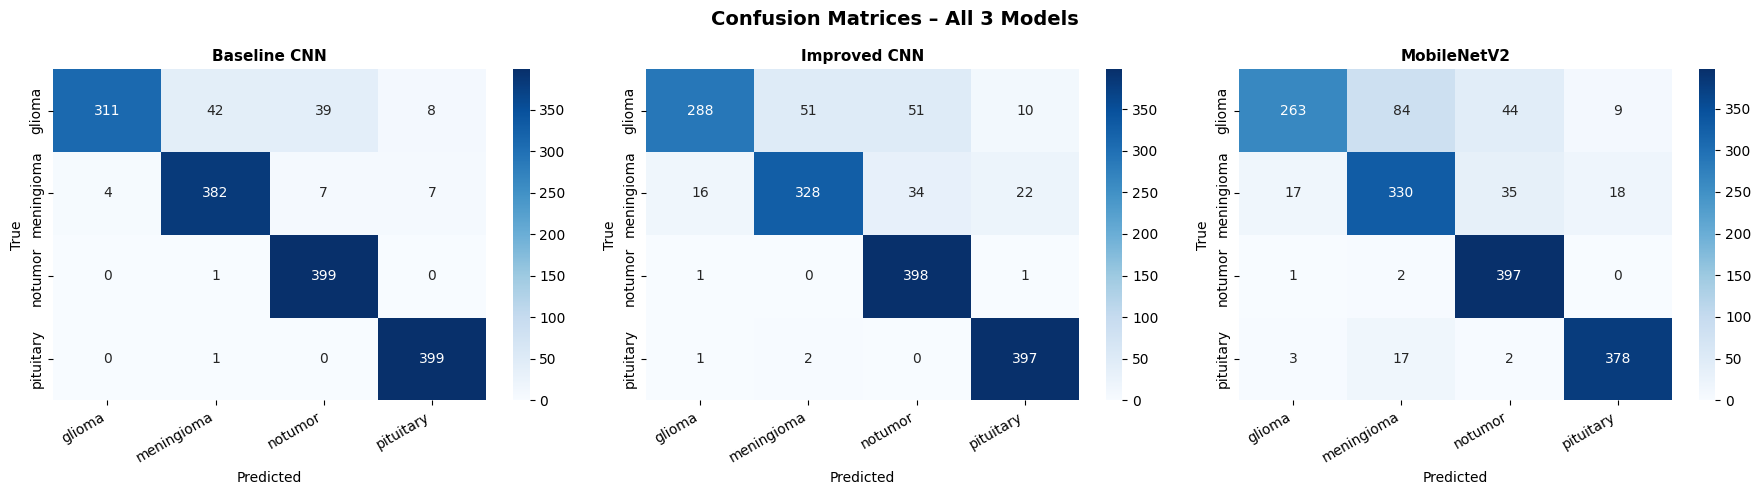

Saved: comparison_confusion_matrices.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name, preds, labels in zip(axes, model_names, all_preds, all_labels):
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.suptitle('Confusion Matrices – All 3 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_confusion_matrices.png', dpi=150)
plt.show()
print('Saved: comparison_confusion_matrices.png')


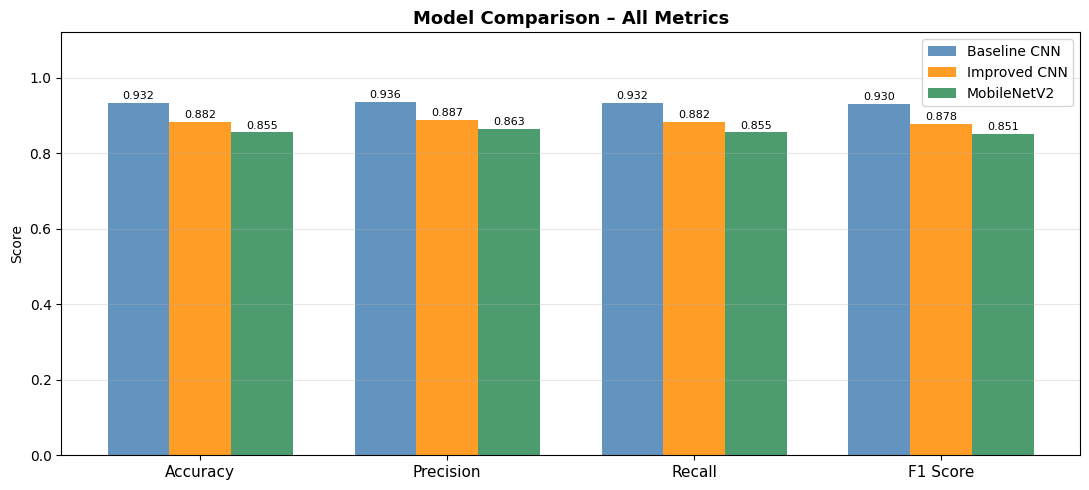

Saved: comparison_metrics_bar.png


In [15]:
metrics_list = ['accuracy', 'precision', 'recall', 'f1']
x      = np.arange(len(metrics_list))
width  = 0.25
colors = ['steelblue', 'darkorange', 'seagreen']

fig, ax = plt.subplots(figsize=(11, 5))

for i, (name, color) in enumerate(zip(model_names, colors)):
    values = [results[name][m] for m in metrics_list]
    bars   = ax.bar(x + i * width, values, width, label=name, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1 Score'], fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Comparison – All Metrics', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_metrics_bar.png', dpi=150)
plt.show()
print('Saved: comparison_metrics_bar.png')


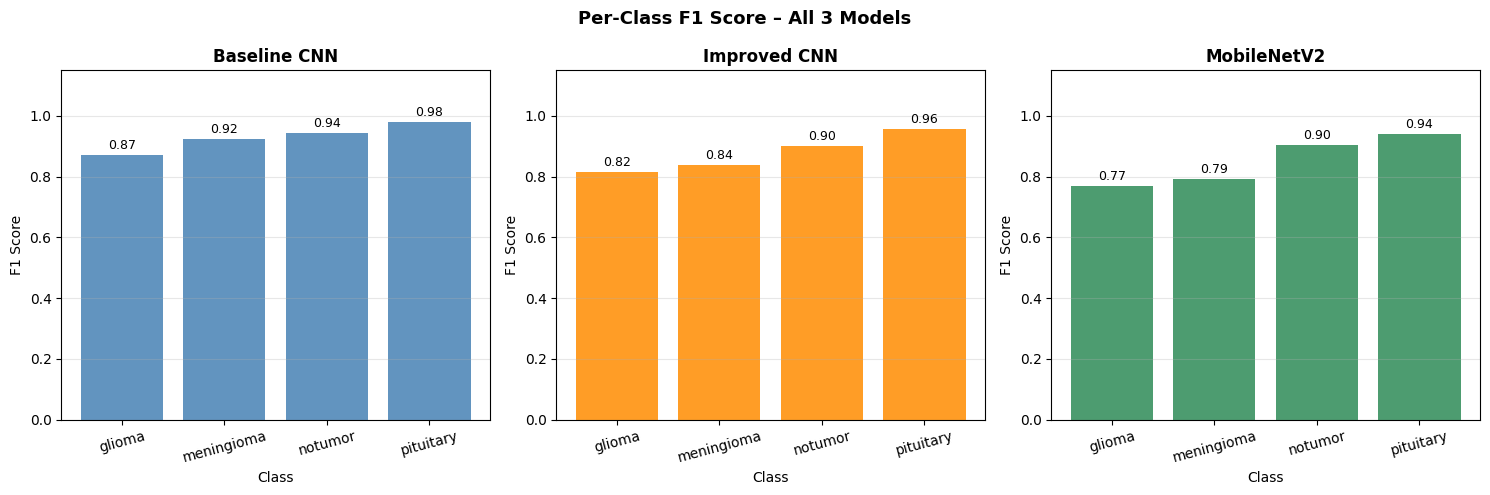

Saved: comparison_per_class_f1.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['steelblue', 'darkorange', 'seagreen']

for ax, name, preds, labels, color in zip(axes, model_names, all_preds, all_labels, colors):
    report = classification_report(labels, preds, target_names=CLASS_NAMES, output_dict=True)
    f1_scores = [report[c]['f1-score'] for c in CLASS_NAMES]
    bars = ax.bar(CLASS_NAMES, f1_scores, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.2f}',
                ha='center', va='bottom', fontsize=9)
    ax.set_title(name, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('F1 Score')
    ax.set_xlabel('Class')
    ax.grid(axis='y', alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=15)

plt.suptitle('Per-Class F1 Score – All 3 Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_per_class_f1.png', dpi=150)
plt.show()
print('Saved: comparison_per_class_f1.png')


In [19]:
best_idx = model_names.index(best)
print(f'Classification Report – {best}')
print('=' * 55)
print(classification_report(
    all_labels[best_idx],
    all_preds[best_idx],
    target_names=CLASS_NAMES
))


Classification Report – Baseline CNN
              precision    recall  f1-score   support

      glioma       0.99      0.78      0.87       400
  meningioma       0.90      0.95      0.92       400
     notumor       0.90      1.00      0.94       400
   pituitary       0.96      1.00      0.98       400

    accuracy                           0.93      1600
   macro avg       0.94      0.93      0.93      1600
weighted avg       0.94      0.93      0.93      1600

